In [1]:
#importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleaanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df = df[df['job_title_short'] == 'Data Analyst']

In [9]:
df_exploded = df.explode('job_skills')
skill_status = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)
skill_status = skill_status.sort_values(by='skill_count', ascending=False).head(10)

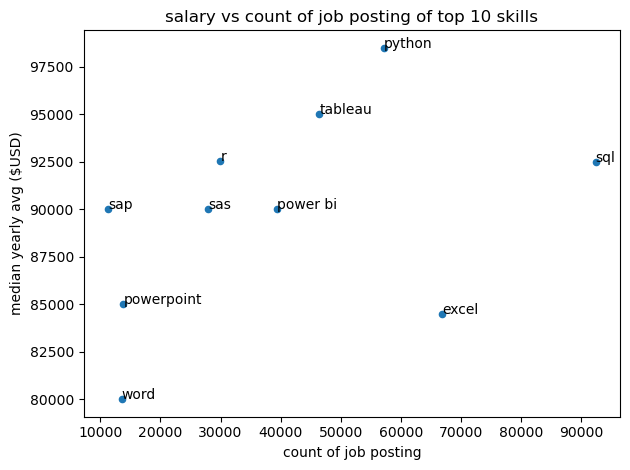

In [14]:
skill_status.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('count of job posting')
plt.ylabel('median yearly avg ($USD)')
plt.title('salary vs count of job posting of top 10 skills')
plt.tight_layout()

for i, txt in enumerate(skill_status.index):
    plt.text(skill_status['skill_count'].iloc[i], skill_status['median_salary'].iloc[i], txt)

plt.show()